Device : cuda
Data : (109819, 28)   pos_weight : 3.57
Baseline models defined.
  SingleModalMLP         params: 12,354
  EarlyFusionMLP         params: 45,698
  AttentionFusion        params: 21,986
  TransformerFusion      params: 5,362
Loaded CausalGNN results.

[B1] Single-Modal MLP (EM only)
  ep  1  loss 0.6899/0.6986  f1 0.5250/0.5070
  ep 10  loss 0.6787/0.7059  f1 0.5443/0.5077
  ep 20  loss 0.6736/0.7070  f1 0.5522/0.5060
  ep 30  loss 0.6690/0.7099  f1 0.5580/0.5108
  ep 40  loss 0.6672/0.7073  f1 0.5583/0.5144
  ep 50  loss 0.6671/0.7072  f1 0.5581/0.5124
  → Macro F1 0.4765  Binary F1 0.2475  AUC 0.4798

[B2] Early Fusion MLP (all modalities)
  ep  1  loss 0.6827/0.7086  f1 0.5272/0.5354
  ep 10  loss 0.6453/0.7185  f1 0.5596/0.5078
  ep 20  loss 0.6263/0.7434  f1 0.5843/0.5193
  ep 30  loss 0.6073/0.7680  f1 0.6024/0.5278
  ep 40  loss 0.5978/0.7802  f1 0.6112/0.5282
  ep 50  loss 0.5947/0.7870  f1 0.6147/0.5288
  → Macro F1 0.4917  Binary F1 0.2451  AUC 0.4735

[B3] Atten

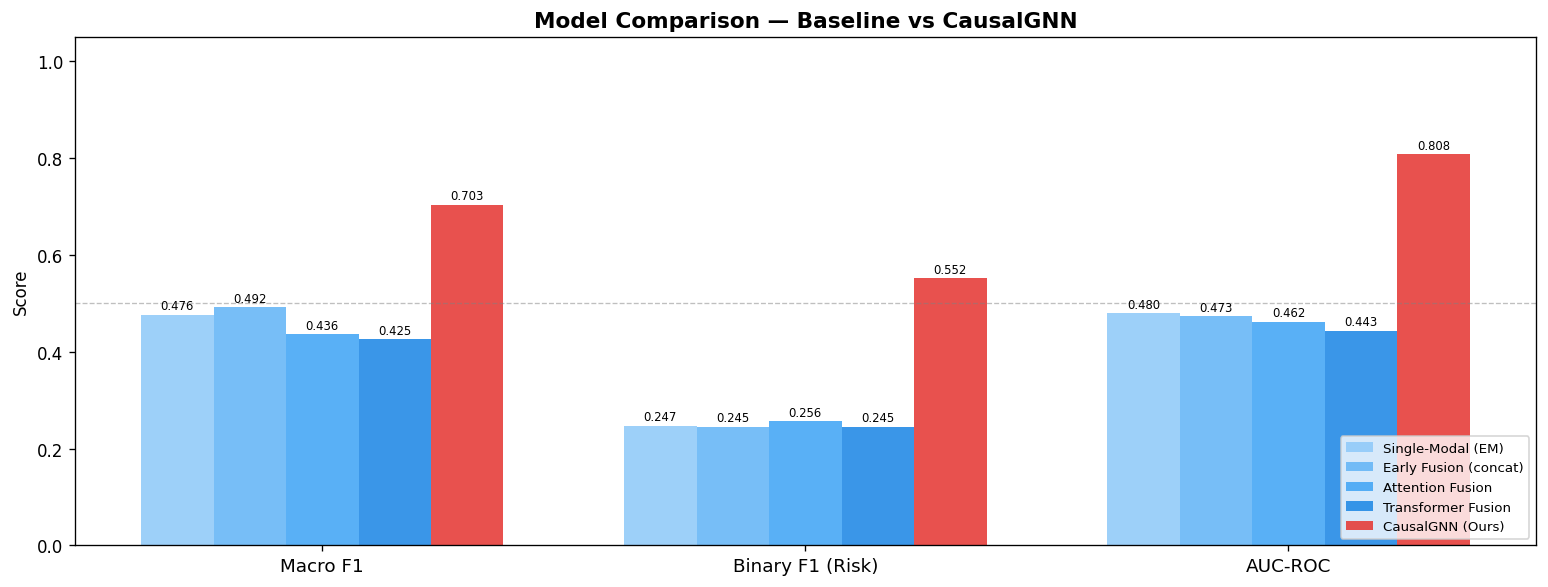

Saved → figures/fig_model_comparison.png

Performance Gain: CausalGNN vs Best Baseline
  Macro F1             CausalGNN 0.7033 vs best baseline 0.4917 (Early Fusion (concat))  gain: +0.2116
  Binary F1 (Risk)     CausalGNN 0.5522 vs best baseline 0.2563 (Attention Fusion)  gain: +0.2959
  AUC-ROC              CausalGNN 0.8079 vs best baseline 0.4798 (Single-Modal (EM))  gain: +0.3281

Baseline Comparison Complete — Summary for Paper

Models evaluated
────────────────
  B1 : Single-Modal MLP    (EM sensors only)
  B2 : Early Fusion MLP    (all modalities, naive concat)
  B3 : Attention Fusion    (EM / SM cross-modal attention)
  B4 : Transformer Fusion  (timestep-as-token)
  B5 : CausalGNN (Ours)   (PCMCI-guided GAT)

Saved
─────
  results/metrics_all_models.csv
  figures/fig_model_comparison.png

Next step → 05_ablation.ipynb



In [1]:
# ============================================================
# Notebook : 04_baseline.ipynb
# Path     : causal_fusion_paper/04_baseline.ipynb
# Purpose  : Baseline comparison for Causal-Guided GNN Fusion
#            Models: Single-Modal | Early Fusion | Attention Fusion
#                    Transformer Fusion | (CausalGNN already trained)
# Author   : [Your Name]
# Created  : 2026-06-11
# ============================================================


# ── Cell 0. Imports & Paths ──────────────────────────────────
import warnings, random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, roc_auc_score, classification_report

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch_geometric.data import Batch

warnings.filterwarnings('ignore')
matplotlib.rcParams.update({'font.family': 'DejaVu Sans', 'figure.dpi': 120})

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

ROOT    = Path().resolve()
FIG_DIR = ROOT / "figures"
RES_DIR = ROOT / "results"
CACHE   = ROOT / "data_cache"
DEVICE  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {DEVICE}")

# Shared constants (must match 03_causal_gnn.ipynb)
FEAT_COLS = ['Activity_IR', 'HeartRate', 'BreathRate', 'StressIndex',
             'Temperature', 'Humidity', 'CO2', 'TVOC']
N_NODES   = len(FEAT_COLS)
WINDOW    = 6
BATCH     = 256
EPOCHS    = 50
LR        = 1e-3
WD        = 1e-4

# Modality slices (for single-modal & attention experiments)
EM_IDX = [0, 4, 5, 6, 7]   # Activity_IR, Temp, Hum, CO2, TVOC
SM_IDX = [1, 2, 3]          # HeartRate, BreathRate, StressIndex


# ── Cell 1. Load Data & Rebuild Splits ──────────────────────
from sklearn.preprocessing import StandardScaler

df = pd.read_pickle(CACHE / "df_new.pkl")

LABEL_MAP_BIN = {'위험': 1, '주의': 1,
                 '수면': 0, '식사': 0, '외출': 0, '기타': 0}
df['label'] = df['Estimation'].map(LABEL_MAP_BIN)
df = df[df['label'].notna()].copy()
df.sort_values(['HH_ID', 'Timestamp'], inplace=True)

pos_weight = (df['label'] == 0).sum() / (df['label'] == 1).sum()
class_weights = torch.tensor([1.0, pos_weight], dtype=torch.float).to(DEVICE)

# Same household split as 03_causal_gnn.ipynb
hh_list  = sorted(df['HH_ID'].unique())
n        = len(hh_list)
rng      = np.random.default_rng(SEED)
hh_shuf  = rng.permutation(hh_list)
train_hh = set(hh_shuf[:int(n * 0.70)])
val_hh   = set(hh_shuf[int(n * 0.70): int(n * 0.70) + int(n * 0.15)])
test_hh  = set(hh_shuf[int(n * 0.70) + int(n * 0.15):])

# Scaler fitted on training households only
scaler   = StandardScaler()
train_df = df[df['HH_ID'].isin(train_hh)]
scaler.fit(train_df[FEAT_COLS].values.astype(np.float32))

feat_all = scaler.transform(df[FEAT_COLS].values.astype(np.float32))
print(f"Data : {df.shape}   pos_weight : {pos_weight:.2f}")


# ── Cell 2. Flat Window Dataset (for non-GNN baselines) ─────
class FlatWindowDataset(Dataset):
    """
    Returns (x_flat, label) where x_flat is (N_nodes × W,) — concatenated.
    Optionally restrict to a subset of feature indices (for single-modal).
    """
    def __init__(self, df, feat_all, feat_idx=None, window=WINDOW):
        self.samples = []
        fidx = feat_idx if feat_idx is not None else list(range(N_NODES))

        for hh, grp in df.groupby('HH_ID'):
            idx   = grp.index
            feats = feat_all[df.index.get_indexer(idx)][:, fidx]  # (T, F)
            labs  = grp['label'].values.astype(np.int64)
            for start in range(0, len(feats) - window):
                x = feats[start: start + window]   # (W, F)
                y = labs[start + window]
                if np.isnan(x).any():
                    continue
                self.samples.append((
                    torch.tensor(x.flatten(), dtype=torch.float),
                    torch.tensor(y,           dtype=torch.long),
                    hh,
                ))

    def __len__(self):  return len(self.samples)
    def __getitem__(self, i):
        x, y, hh = self.samples[i]
        return x, y

def make_flat_loaders(feat_idx=None):
    def split(hh_set):
        ds = FlatWindowDataset(df[df['HH_ID'].isin(hh_set)],
                               feat_all, feat_idx)
        return DataLoader(ds, batch_size=BATCH, shuffle=True)
    return (split(train_hh), split(val_hh), split(test_hh))


# ── Cell 3. Sequence Dataset (for Transformer baseline) ─────
class SeqWindowDataset(Dataset):
    """Returns (x_seq, label) where x_seq is (W, N_nodes)."""
    def __init__(self, df, feat_all, window=WINDOW):
        self.samples = []
        for hh, grp in df.groupby('HH_ID'):
            idx   = grp.index
            feats = feat_all[df.index.get_indexer(idx)]   # (T, N)
            labs  = grp['label'].values.astype(np.int64)
            for start in range(0, len(feats) - window):
                x = feats[start: start + window]
                y = labs[start + window]
                if np.isnan(x).any():
                    continue
                self.samples.append((
                    torch.tensor(x, dtype=torch.float),
                    torch.tensor(y, dtype=torch.long),
                ))
    def __len__(self):  return len(self.samples)
    def __getitem__(self, i): return self.samples[i]

def make_seq_loaders():
    def split(hh_set):
        ds = SeqWindowDataset(df[df['HH_ID'].isin(hh_set)], feat_all)
        return DataLoader(ds, batch_size=BATCH, shuffle=True)
    return (split(train_hh), split(val_hh), split(test_hh))


# ── Cell 4. Baseline Model Definitions ──────────────────────

# [B1] Single-Modal MLP (EM only)
class SingleModalMLP(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64),    nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 2),
        )
    def forward(self, x): return self.net(x)


# [B2] Early Fusion MLP (all modalities concatenated)
class EarlyFusionMLP(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128),   nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 2),
        )
    def forward(self, x): return self.net(x)


# [B3] Attention-Based Fusion
class AttentionFusion(nn.Module):
    """
    Per-modality encoders → cross-modal attention → classifier.
    EM and SM streams encoded separately, then fused via attention.
    """
    def __init__(self, em_dim, sm_dim, hidden=64):
        super().__init__()
        self.em_enc = nn.Sequential(
            nn.Linear(em_dim, hidden), nn.ReLU())
        self.sm_enc = nn.Sequential(
            nn.Linear(sm_dim, hidden), nn.ReLU())
        self.attn   = nn.MultiheadAttention(hidden, num_heads=4,
                                            batch_first=True, dropout=0.1)
        self.clf    = nn.Sequential(
            nn.Linear(hidden, 32), nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 2),
        )
    def forward(self, x):
        # x : (B, W*N_flat) — split by modality index
        w     = WINDOW
        n_em  = len(EM_IDX)
        n_sm  = len(SM_IDX)
        # Reshape to (B, W, N) then select
        xr    = x.view(x.size(0), w, N_NODES)
        em    = self.em_enc(xr[:, :, EM_IDX].reshape(x.size(0), -1))  # (B, H)
        sm    = self.sm_enc(xr[:, :, SM_IDX].reshape(x.size(0), -1))  # (B, H)
        # Stack as sequence of 2 tokens → attention
        tokens = torch.stack([em, sm], dim=1)   # (B, 2, H)
        out, _ = self.attn(tokens, tokens, tokens)
        fused  = out.mean(dim=1)                # (B, H)
        return self.clf(fused)


# [B4] Transformer Fusion
class TransformerFusion(nn.Module):
    """
    Treat each timestep as a token (d_model = N_nodes).
    Standard Transformer encoder → mean pool → classifier.
    """
    def __init__(self, d_model=N_NODES, nhead=4,
                 num_layers=2, dim_ff=128, dropout=0.1):
        super().__init__()
        enc_layer  = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=dim_ff, dropout=dropout,
            batch_first=True)
        self.enc   = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.clf   = nn.Sequential(
            nn.Linear(d_model, 32), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 2),
        )
    def forward(self, x):
        # x : (B, W, N_nodes)
        out = self.enc(x)          # (B, W, d_model)
        return self.clf(out.mean(dim=1))


print("Baseline models defined.")
for name, Model, args in [
    ("SingleModalMLP",  SingleModalMLP,  (len(EM_IDX) * WINDOW,)),
    ("EarlyFusionMLP",  EarlyFusionMLP,  (N_NODES * WINDOW,)),
    ("AttentionFusion", AttentionFusion,  (len(EM_IDX)*WINDOW, len(SM_IDX)*WINDOW)),
    ("TransformerFusion", TransformerFusion, ()),
]:
    m = Model(*args)
    n_p = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f"  {name:<22} params: {n_p:,}")


# ── Cell 5. Generic Training Function ───────────────────────
def train_model(model, train_loader, val_loader,
                is_seq=False, epochs=EPOCHS):
    crit  = nn.CrossEntropyLoss(weight=class_weights)
    opt   = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    best_f1, best_state = 0., None
    hist = {'tl': [], 'vl': [], 'tf': [], 'vf': []}

    for ep in range(1, epochs + 1):
        for phase, loader, train in [('tr', train_loader, True),
                                      ('vl', val_loader,   False)]:
            model.train() if train else model.eval()
            tot_loss, preds, trues = 0., [], []
            ctx = torch.enable_grad() if train else torch.no_grad()
            with ctx:
                for batch in loader:
                    x, y = batch[0].to(DEVICE), batch[1].to(DEVICE)
                    logits = model(x)
                    loss   = crit(logits, y)
                    if train:
                        opt.zero_grad(); loss.backward()
                        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                        opt.step()
                    tot_loss += loss.item() * len(y)
                    preds.extend(logits.argmax(1).cpu().numpy())
                    trues.extend(y.cpu().numpy())
            n  = len(trues)
            f1 = f1_score(trues, preds, average='macro', zero_division=0)
            hist['tl' if phase=='tr' else 'vl'].append(tot_loss / n)
            hist['tf' if phase=='tr' else 'vf'].append(f1)
        sched.step()
        if hist['vf'][-1] > best_f1:
            best_f1   = hist['vf'][-1]
            best_state = {k: v.cpu().clone()
                          for k, v in model.state_dict().items()}
        if ep % 10 == 0 or ep == 1:
            print(f"  ep{ep:>3}  loss {hist['tl'][-1]:.4f}/{hist['vl'][-1]:.4f}"
                  f"  f1 {hist['tf'][-1]:.4f}/{hist['vf'][-1]:.4f}")
    model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})
    return model, hist, best_f1


def evaluate_model(model, test_loader, is_seq=False):
    model.eval()
    preds, trues, probs_list = [], [], []
    with torch.no_grad():
        for batch in test_loader:
            x, y    = batch[0].to(DEVICE), batch[1].to(DEVICE)
            logits  = model(x)
            prob    = F.softmax(logits, dim=1)[:, 1]
            preds.extend(logits.argmax(1).cpu().numpy())
            trues.extend(y.cpu().numpy())
            probs_list.extend(prob.cpu().numpy())
    macro_f1 = f1_score(trues, preds, average='macro',  zero_division=0)
    bin_f1   = f1_score(trues, preds, average='binary', zero_division=0)
    auc      = roc_auc_score(trues, probs_list)
    return macro_f1, bin_f1, auc, trues, preds


# ── Cell 6. Run All Baselines ────────────────────────────────
all_results = []

# Load CausalGNN result (already computed)
causal_metrics = pd.read_csv(RES_DIR / "metrics_causal_gnn.csv")
all_results.append({
    'Model':     'CausalGNN (Ours)',
    'Macro_F1':  causal_metrics['macro_f1'].values[0],
    'Binary_F1': causal_metrics['binary_f1'].values[0],
    'AUC_ROC':   causal_metrics['auc_roc'].values[0],
})
print("Loaded CausalGNN results.")

# ── B1: Single-Modal (EM only)
print("\n[B1] Single-Modal MLP (EM only)")
tr, vl, te = make_flat_loaders(feat_idx=EM_IDX)
m_b1 = SingleModalMLP(in_dim=len(EM_IDX) * WINDOW).to(DEVICE)
m_b1, _, _ = train_model(m_b1, tr, vl)
mf, bf, au, _, _ = evaluate_model(m_b1, te)
all_results.append({'Model':'Single-Modal (EM)',
                    'Macro_F1':round(mf,4),'Binary_F1':round(bf,4),'AUC_ROC':round(au,4)})
print(f"  → Macro F1 {mf:.4f}  Binary F1 {bf:.4f}  AUC {au:.4f}")

# ── B2: Early Fusion (concat all)
print("\n[B2] Early Fusion MLP (all modalities)")
tr, vl, te = make_flat_loaders()
m_b2 = EarlyFusionMLP(in_dim=N_NODES * WINDOW).to(DEVICE)
m_b2, _, _ = train_model(m_b2, tr, vl)
mf, bf, au, _, _ = evaluate_model(m_b2, te)
all_results.append({'Model':'Early Fusion (concat)',
                    'Macro_F1':round(mf,4),'Binary_F1':round(bf,4),'AUC_ROC':round(au,4)})
print(f"  → Macro F1 {mf:.4f}  Binary F1 {bf:.4f}  AUC {au:.4f}")

# ── B3: Attention-Based Fusion
print("\n[B3] Attention-Based Fusion")
tr, vl, te = make_flat_loaders()
m_b3 = AttentionFusion(em_dim=len(EM_IDX)*WINDOW,
                       sm_dim=len(SM_IDX)*WINDOW).to(DEVICE)
m_b3, _, _ = train_model(m_b3, tr, vl)
mf, bf, au, _, _ = evaluate_model(m_b3, te)
all_results.append({'Model':'Attention Fusion',
                    'Macro_F1':round(mf,4),'Binary_F1':round(bf,4),'AUC_ROC':round(au,4)})
print(f"  → Macro F1 {mf:.4f}  Binary F1 {bf:.4f}  AUC {au:.4f}")

# ── B4: Transformer Fusion
print("\n[B4] Transformer Fusion")
tr, vl, te = make_seq_loaders()
m_b4 = TransformerFusion().to(DEVICE)
m_b4, _, _ = train_model(m_b4, tr, vl)
mf, bf, au, *_ = evaluate_model(m_b4, te)
all_results.append({'Model':'Transformer Fusion',
                    'Macro_F1':round(mf,4),'Binary_F1':round(bf,4),'AUC_ROC':round(au,4)})
print(f"  → Macro F1 {mf:.4f}  Binary F1 {bf:.4f}  AUC {au:.4f}")

# ── Compile results table
df_res = pd.DataFrame(all_results)
# Reorder: CausalGNN last for emphasis
order  = ['Single-Modal (EM)', 'Early Fusion (concat)',
          'Attention Fusion', 'Transformer Fusion', 'CausalGNN (Ours)']
df_res = df_res.set_index('Model').reindex(order).reset_index()
df_res.to_csv(RES_DIR / "metrics_all_models.csv", index=False)
print("\n" + "="*60)
print("All Models — Test Performance")
print("="*60)
print(df_res.to_string(index=False))
print("Saved → results/metrics_all_models.csv")


# ── Cell 7. Comparison Figure (Paper Table / Bar Chart) ─────
metrics = ['Macro_F1', 'Binary_F1', 'AUC_ROC']
labels  = ['Macro F1', 'Binary F1 (Risk)', 'AUC-ROC']
models  = df_res['Model'].tolist()
colors  = ['#90CAF9', '#64B5F6', '#42A5F5', '#1E88E5', '#E53935']
x       = np.arange(len(metrics))
w       = 0.15

fig, ax = plt.subplots(figsize=(13, 5))
for i, (model, color) in enumerate(zip(models, colors)):
    vals = [df_res.loc[df_res['Model']==model, m].values[0] for m in metrics]
    bars = ax.bar(x + i * w, vals, w, label=model, color=color, alpha=0.88)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x + w * (len(models)-1) / 2)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.set_title('Model Comparison — Baseline vs CausalGNN',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=8, loc='lower right')
ax.axhline(0.5, color='gray', lw=0.8, ls='--', alpha=0.5)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved → figures/fig_model_comparison.png")


# ── Cell 8. Gain Analysis ────────────────────────────────────
print("\n" + "="*60)
print("Performance Gain: CausalGNN vs Best Baseline")
print("="*60)

causal_row  = df_res[df_res['Model'] == 'CausalGNN (Ours)'].iloc[0]
baseline_df = df_res[df_res['Model'] != 'CausalGNN (Ours)']

for m, label in zip(metrics, labels):
    best_base = baseline_df[m].max()
    gain      = causal_row[m] - best_base
    best_name = baseline_df.loc[baseline_df[m].idxmax(), 'Model']
    sign      = '+' if gain >= 0 else ''
    print(f"  {label:<20} CausalGNN {causal_row[m]:.4f} "
          f"vs best baseline {best_base:.4f} ({best_name})"
          f"  gain: {sign}{gain:.4f}")


# ── Cell 9. Summary ─────────────────────────────────────────
print(f"""
{'='*60}
Baseline Comparison Complete — Summary for Paper
{'='*60}

Models evaluated
────────────────
  B1 : Single-Modal MLP    (EM sensors only)
  B2 : Early Fusion MLP    (all modalities, naive concat)
  B3 : Attention Fusion    (EM / SM cross-modal attention)
  B4 : Transformer Fusion  (timestep-as-token)
  B5 : CausalGNN (Ours)   (PCMCI-guided GAT)

Saved
─────
  results/metrics_all_models.csv
  figures/fig_model_comparison.png

Next step → 05_ablation.ipynb
""")